In [ ]:
# For this analysis the data was from Lisboa et al., (2024). This was made available to us by the authors. The following processes were then applied to the Lisboa et al., (2024) for analysis. 
# Script developed by Poppy Webb
 # Step 1 = Load and Reproject: 2000 & 2020 Lisboa land cover data 

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

def reproject_raster(input_raster, output_raster, dst_crs='EPSG:4326',
                     resampling=Resampling.nearest):
    """
    Reproject a raster to a new CRS and save it.

    Parameters
    ----------
    input_raster : str
        Path to the input raster.
    output_raster : str
        Path to the output (reprojected) raster.
    dst_crs : str, optional
        Target CRS in EPSG format (default is 'EPSG:4326').
    resampling : rasterio.warp.Resampling, optional
        Resampling method (default is Resampling.nearest).
    """
    with rasterio.open(input_raster) as src:
        # Calculate new transform/shape
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )

        # Update metadata
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Reproject and write to disk
        with rasterio.open(output_raster, 'w', **kwargs) as dst:
            for band in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, band),
                    destination=rasterio.band(dst, band),
                    src_crs=src.crs,
                    dst_crs=dst_crs,
                    resampling=resampling
                )

In [ ]:

# Reproject raster for 2000 LULC dataset 
reproject_raster(
    r'/Data/landuse/lulc_map_2000_BC.tif', # File path for original 2000 dataset available from Lisboa et al., (2024). 
    r'/Data/landuse/lulc_map_2000_BC_reproject.tif' # File path for re-projected 2000 dataset
)

# Reproject raster for 2020 LULC dataset 
reproject_raster(
    r'/Data/landuse/lulc_map_2020_BC.tif', # File path for original 2000 dataset available from Lisboa et al., (2024). 
    r'/Data/landuse/lulc_map_2020_BC.tif', # File path for re-projected 2020 dataset
)

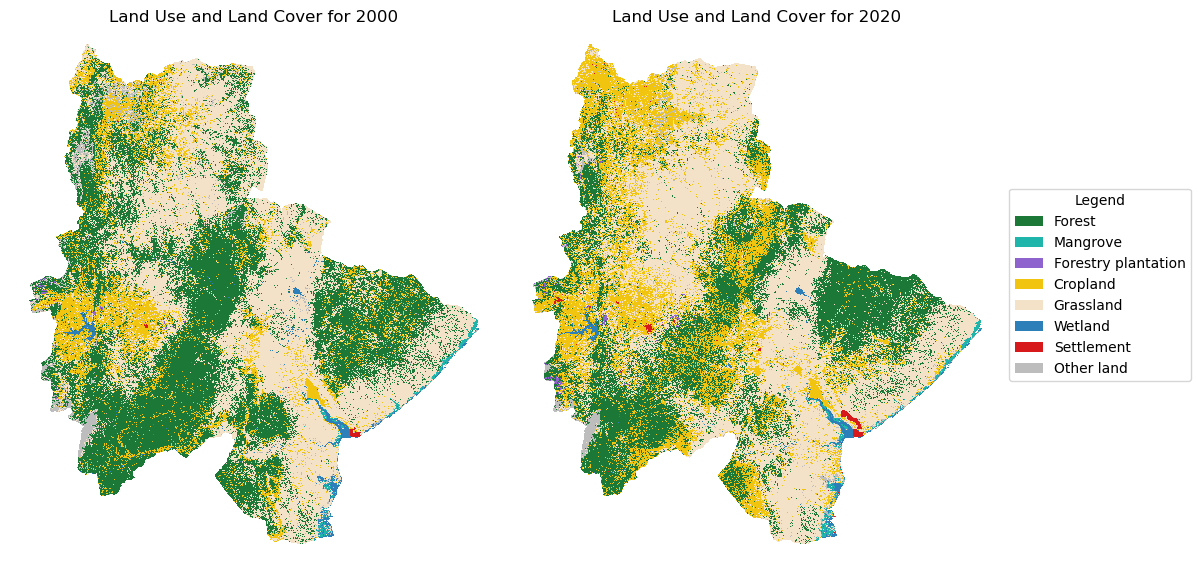

In [ ]:
 # Step 1.1 = Check and plot the Reprojected 2000 & 2020 land cover 
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# -----------------------
# Inputs Lisboa reprojected data. 
# -----------------------
r2000 = r"/Data/landuse/lulc_map_2000_BC_reproject.tif"
r2020 = r"/Data/landuse/lulc_map_2020_BC_reproject.tif"

# -----------------------
# Classes & colours (using same style and colours from Lisboa et al., 2024)
# -----------------------
CLASS_LABELS = {
    1: "Forest",
    2: "Mangrove",
    3: "Forestry plantation",
    4: "Cropland",
    5: "Grassland",
    6: "Wetland",
    7: "Settlement",
    8: "Other land",
}
COLORS = [
    "#1B7837",  # 1 Forest
    "#1FB5AA",  # 2 Mangrove
    "#8E63CE",  # 3 Forestry plantation
    "#F1C40F",  # 4 Cropland
    "#F3E2C7",  # 5 Grassland
    "#2C7FB8",  # 6 Wetland
    "#D7191C",  # 7 Settlement
    "#BDBDBD",  # 8 Other land
]
cmap = ListedColormap(COLORS)
# -----------------------
# Read rasters
# -----------------------
def read(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
        bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    return arr, extent

a2000, ex2000 = read(r2000)
a2020, ex2020 = read(r2020)

# Mask NoData (255)
a2000 = np.ma.masked_where(a2000 == 255, a2000)
a2020 = np.ma.masked_where(a2020 == 255, a2020)
# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(a2000, cmap=cmap, extent=ex2000, interpolation="nearest",
               vmin=1, vmax=8)
axes[0].set_title("Land Use and Land Cover for 2000")
axes[0].axis("off")

axes[1].imshow(a2020, cmap=cmap, extent=ex2020, interpolation="nearest",
               vmin=1, vmax=8)
axes[1].set_title("Land Use and Land Cover for 2020")
axes[1].axis("off")

# -----------------------
# Legend (single, shared)
# -----------------------
legend_handles = [
    Patch(facecolor=COLORS[i-1], label=CLASS_LABELS[i])
    for i in CLASS_LABELS
]

fig.legend(
    handles=legend_handles,
    title="Legend",
    loc="center right",
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [ ]:
# Step 2: Reclassify the Lisboa into land classes from Vito: To the closest corresponding class. 

import numpy as np

def reclassify(input_path, output_path, reclass_map):
    """
    Reclassify the Lisboa raster's to values of Vito 2019 

    Parameters
    ----------
    input_path : str
        Path to the input raster (e.g. reprojected file).
    output_path : str
        Path to the output reclassified raster.
    reclass_map : dict
        Mapping of {original_value: new_value}.
    """
    with rasterio.open(input_path) as src:
        profile = src.profile
        data = src.read(1)

        # Create a copy to hold reclassified data
        reclassed = np.copy(data)

        # Apply reclassification mapping
        for orig_val, new_val in reclass_map.items():
            reclassed[data == orig_val] = new_val

        # Update dtype if needed (here, uint8 is fine)
        profile.update(dtype=rasterio.uint8)

        # Save to disk
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(reclassed.astype(rasterio.uint8), 1)

In [ ]:
reclass_map = {
    1: 114,
    2: 122,
    3: 126,
    4: 40,
    5: 30,
    6: 90,
    7: 50,
    8: 60,
    255: 255  # keep nodata
}
 # Using the same labels for Lisboa = to matching classes/ or should I use the VIto ones ? 
CLASS_LABELS = {
    30:  "Grassland",
    40:  "Cropland",
    50:  "Settlement",
    60:  "Other land ",
    90:  "Wetland",
    114: "Forest",
    122: "Mangrove",
    126: "Forestry Plantation",
    255: "NoData",
}

base = "/Data/landuse"

# Input/output pairs for both years
rasters = [
    (f"{base}/lulc_map_2000_BC_reproject.tif", f"{base}/lulc_map_2000_BC_reclassified.tif"),
    (f"{base}/lulc_map_2020_BC_reproject.tif", f"{base}/lulc_map_2020_BC_reclassified.tif"),
]
# Run reclassification for both rasters
for in_path, out_path in rasters:
    print(f"Reclassifying: {in_path}")
    reclassify(in_path, out_path, reclass_map)
    print(f"✅ Saved reclassified raster to: {out_path}\n")

Reclassifying: /Users/poppywebb/Documents/GECP Masters/Data_Poppy/LULC_data/lulc_map_2000_BC_reproject.tif
✅ Saved reclassified raster to: /Users/poppywebb/Documents/GECP Masters/Data_Poppy/LULC_data/lulc_map_2000_BC_reclassified.tif

Reclassifying: /Users/poppywebb/Documents/GECP Masters/Data_Poppy/LULC_data/lulc_map_2020_BC_reproject.tif
✅ Saved reclassified raster to: /Users/poppywebb/Documents/GECP Masters/Data_Poppy/LULC_data/lulc_map_2020_BC_reclassified.tif



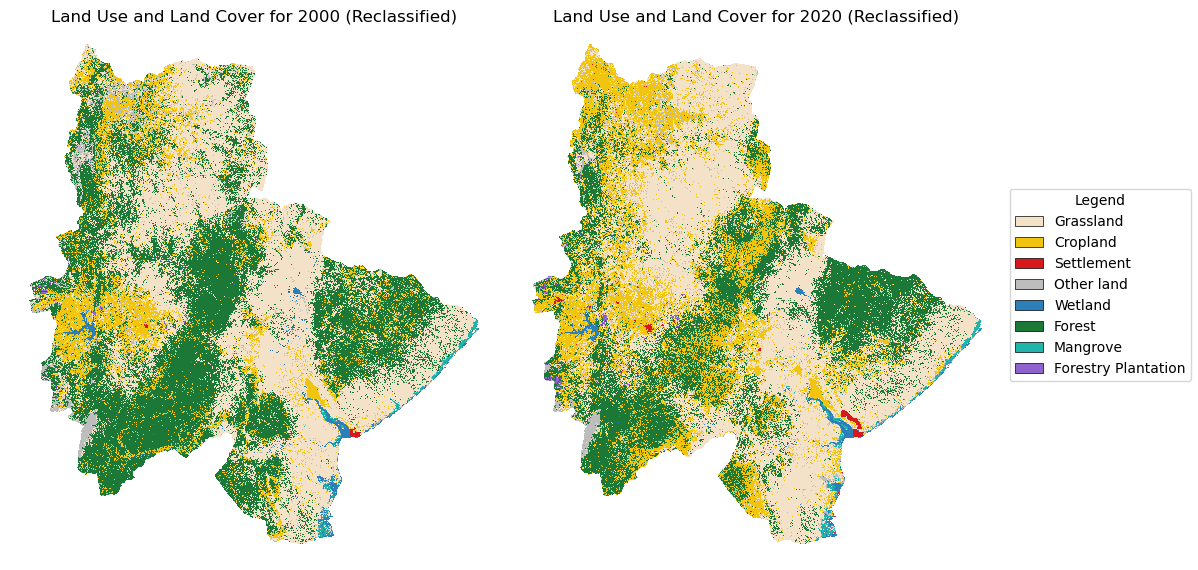

In [ ]:
# Step 2.1 Plot - Reclassified to check it worked

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

reclassed_path_1 = r"/Data/landuse/lulc_map_2000_BC_reclassified.tif"
reclassed_path_2 = r"/Data/landuse/lulc_map_2020_BC_reclassified.tif"

CLASS_LABELS = {
    30:  "Grassland",
    40:  "Cropland",
    50:  "Settlement",
    60:  "Other land",
    90:  "Wetland",
    114: "Forest",
    122: "Mangrove",
    126: "Forestry Plantation",
    255: "NoData",
}

COLORS = {
    30:  "#F3E2C7",
    40:  "#F1C40F",
    50:  "#D7191C",
    60:  "#BDBDBD",
    90:  "#2C7FB8",
    114: "#1B7837",
    122: "#1FB5AA",
    126: "#8E63CE",
    255: "#FFFFFF",
}

# Read rasters
def read(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
        bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    return arr, extent

a2000, ex2000 = read(reclassed_path_1)
a2020, ex2020 = read(reclassed_path_2)

# Mask NoData
a2000 = np.ma.masked_where(a2000 == 255, a2000)
a2020 = np.ma.masked_where(a2020 == 255, a2020)

# ---- Build discrete cmap + norm for your class codes ----
classes = [30, 40, 50, 60, 90, 114, 122, 126]  # exclude 255 from display mapping
cmap = ListedColormap([COLORS[c] for c in classes])

# boundaries centered between integer codes, so each code maps cleanly
bounds = [c - 0.5 for c in classes] + [classes[-1] + 0.5]
norm = BoundaryNorm(bounds, cmap.N)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(a2000, cmap=cmap, norm=norm, extent=ex2000, interpolation="nearest")
axes[0].set_title("Land Use and Land Cover for 2000 (Reclassified)")
axes[0].axis("off")

axes[1].imshow(a2020, cmap=cmap, norm=norm, extent=ex2020, interpolation="nearest")
axes[1].set_title("Land Use and Land Cover for 2020 (Reclassified)")
axes[1].axis("off")

# Legend (sorted, correct keys)
legend_handles = [
    Patch(facecolor=COLORS[c], edgecolor="black", linewidth=0.5, label=CLASS_LABELS[c])
    for c in classes
]
fig.legend(handles=legend_handles, title="Legend", loc="center right", frameon=True)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [ ]:
# Step 3 - Clip the reclassified to the basin extent (used for the wflow model)

import geopandas as gpd
import rasterio
from rasterio.mask import mask

# ---- Paths ----
raster_path_2000 = r"/Data/landuse/lulc_map_2000_BC_reclassified.tif"
raster_path_2020 = r"/Data/landuse/lulc_map_2020_BC_reclassified.tif"

# Wflow basins file
region_path = r"/Data/gis_files/basins.geojson"

out_path_2000 = r"/Data/landuse/lulc_map_2000_BC_reclassified_clipped_basins.tif"
out_path_2020 = r"/Data/landuse/lulc_map_2020_BC_reclassified_clipped_basins.tif"

# ---- Read region once ----
region_gdf = gpd.read_file(region_path)

def clip_raster_to_region(in_raster: str, out_raster: str, region_gdf: gpd.GeoDataFrame) -> None:
    with rasterio.open(in_raster) as src:
        # Reproject region to raster CRS if needed
        reg = region_gdf
        if reg.crs != src.crs:
            reg = reg.to_crs(src.crs)

        shapes = [geom.__geo_interface__ for geom in reg.geometry]

        out_image, out_transform = mask(
            src,
            shapes,
            crop=True,
            nodata=src.nodata
        )

        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": src.nodata
        })

    with rasterio.open(out_raster, "w", **out_meta) as dst:
        dst.write(out_image)

    print(f"✅ Clipped raster written to: {out_raster}")

# ---- Run for both files ----
clip_raster_to_region(raster_path_2000, out_path_2000, region_gdf)
clip_raster_to_region(raster_path_2020, out_path_2020, region_gdf)


✅ Clipped raster written to: /Users/poppywebb/Documents/GECP Masters/Data_Poppy/LULC_data/lulc_map_2000_BC_reclassified_clipped_basins.tif
✅ Clipped raster written to: /Users/poppywebb/Documents/GECP Masters/Data_Poppy/LULC_data/lulc_map_2020_BC_reclassified_clipped_basins.tif


In [ ]:

# Step 3.1 - CLip the reclassified to the basin extent (used for the wflow model)
import geopandas as gpd
import rasterio
from rasterio.mask import mask

# ---- Paths ----
raster_path_2000 = r"/Data/landuse/lulc_map_2000_BC_reclassified.tif"
raster_path_2020 = r"/Data/landuse/lulc_map_2020_BC_reclassified.tif"

region_path = r"/Data/landuse/basins.geojson"

out_path_2000    = r"/Data/landuse/lulc_map_2000_BC_reclassified_clipped_basins.tif"
out_path_2020    = r"/Data/landuse/lulc_map_2020_BC_reclassified_clipped_basins.tif"

# ---- Read region ----
region_gdf = gpd.read_file(region_path)

with rasterio.open(raster_path_2000, raster_path_2020) as src:

    # Reproject region to raster CRS if needed
    if region_gdf.crs != src.crs:
        region_gdf = region_gdf.to_crs(src.crs)

    # Convert geometry to GeoJSON-like mapping
    shapes = [geom.__geo_interface__ for geom in region_gdf.geometry]

    # Clip raster
    out_image, out_transform = mask(
        src,
        shapes,
        crop=True,
        nodata=src.nodata
    )

    # Update metadata
    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "nodata": src.nodata
    })

# ---- Write clipped raster ----
with rasterio.open(out_path_2000,out_path_2020, "w", **out_meta) as dst:
    dst.write(out_image)

print("✅ Clipped raster written to:")
print(out_path_2000, out_path_2020)


DriverCapabilityError: mode must be one of 'r', 'r+', or 'w', not /Users/poppywebb/Documents/GECP Masters/Data_Poppy/LULC_data/lulc_map_2020_BC_reclassified.tif

2000 unique classes: [ 30  40  50  60  90 114 122 126 255]
2020 unique classes: [ 30  40  50  60  90 114 122 126 255]


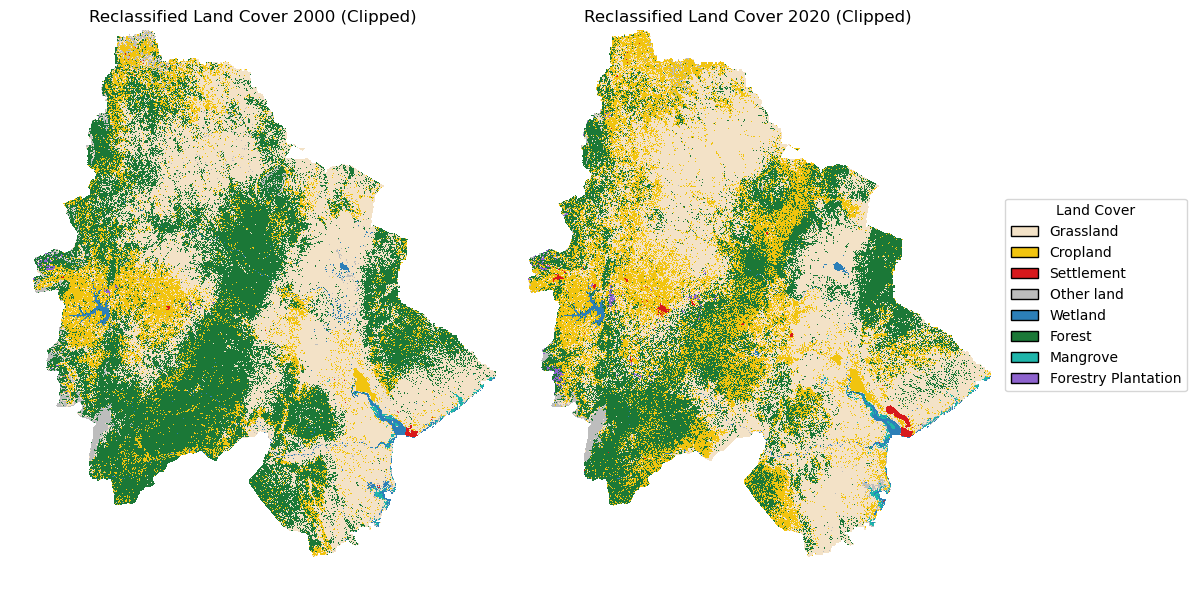

In [ ]:
# 3.1 Plot to make sure it has successfully clipped to the basin extent

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

CLASS_LABELS = {
    30:  "Grassland",
    40:  "Cropland",
    50:  "Settlement",
    60:  "Other land",
    90:  "Wetland",
    114: "Forest",
    122: "Mangrove",
    126: "Forestry Plantation",
    255: "NoData",
}

COLORS = {
    30:  "#F3E2C7",
    40:  "#F1C40F",
    50:  "#D7191C",
    60:  "#BDBDBD",
    90:  "#2C7FB8",
    114: "#1B7837",
    122: "#1FB5AA",
    126: "#8E63CE",
    255: "#FFFFFF",
}

# 🔒 Fixed order — MUST stay identical everywhere
PLOT_CLASSES = [30, 40, 50, 60, 90, 114, 122, 126, 255]

clipped_path_2000 = r"/Data/landuse/lulc_map_2000_BC_reclassified_clipped_basins.tif"
clipped_path_2020 = r"Data/landuse/LULC_data/lulc_map_2020_BC_reclassified_clipped_basins.tif"


# ---- Read raster helper ----
def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    return data, extent


data_2000, extent_2000 = read_raster(clipped_path_2000)
data_2020, extent_2020 = read_raster(clipped_path_2020)

print("2000 unique classes:", np.unique(data_2000))
print("2020 unique classes:", np.unique(data_2020))

# Mask NoData
data_2000 = np.ma.masked_where(data_2000 == 255, data_2000)
data_2020 = np.ma.masked_where(data_2020 == 255, data_2020)

# ---- Build fixed colormap + norm ----
cmap = ListedColormap([COLORS[c] for c in PLOT_CLASSES])
bounds = [c - 0.5 for c in PLOT_CLASSES] + [PLOT_CLASSES[-1] + 0.5]
norm = BoundaryNorm(bounds, cmap.N)

# ---- Plot side-by-side ----
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(
    data_2000,
    cmap=cmap,
    norm=norm,
    extent=extent_2000,
    interpolation="nearest",
)
axes[0].set_title("Reclassified Land Cover 2000 (Clipped)")
axes[0].set_axis_off()

axes[1].imshow(
    data_2020,
    cmap=cmap,
    norm=norm,
    extent=extent_2020,
    interpolation="nearest",
)
axes[1].set_title("Reclassified Land Cover 2020 (Clipped)")
axes[1].set_axis_off()

# ---- Legend (only classes present, colours fixed) ----
present = set(np.unique(data_2000.compressed())) | set(np.unique(data_2020.compressed()))

legend_handles = [
    Patch(facecolor=COLORS[c], edgecolor="black", label=CLASS_LABELS[c])
    for c in PLOT_CLASSES
    if c in present and c != 255
]
fig.legend(
    handles=legend_handles,
    title="Land Cover",
    loc="center right",
    frameon=True,
)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


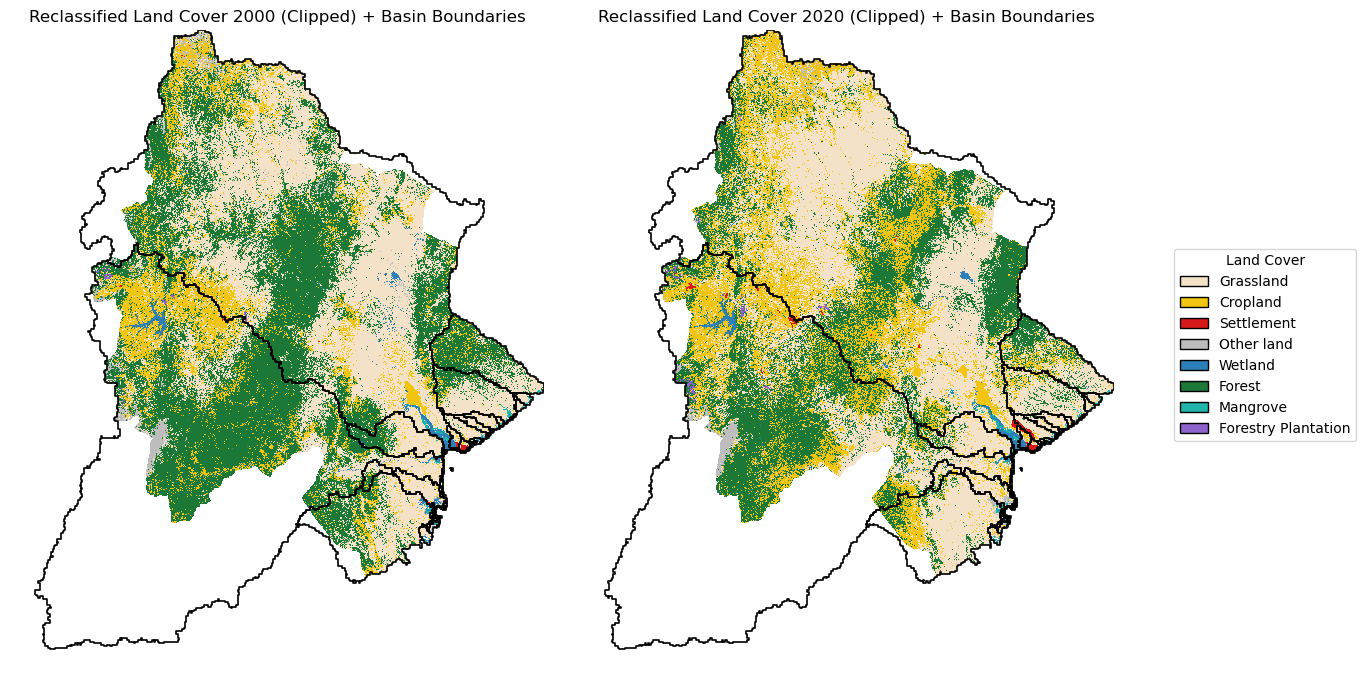

In [ ]:
# 3.2 Overlay with the basin to show everything is there - and where the missing data is (2000 + 2020)

import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# ---- Paths ----
clipped_raster_2000 = r"/Data/landuse/lulc_map_2000_BC_reclassified_clipped_basins.tif"
clipped_raster_2020 = r"/Data/landuse/lulc_map_2020_BC_reclassified_clipped_basins.tif"
basins_path = r"/Data/gis_files/basins.geojson"

# ---- Classes & colours (CONSISTENT with your earlier plots) ----
CLASS_LABELS = {
    30:  "Grassland",
    40:  "Cropland",
    50:  "Settlement",
    60:  "Other land",
    90:  "Wetland",
    114: "Forest",
    122: "Mangrove",
    126: "Forestry Plantation",
    255: "NoData",
}

COLORS = {
    30:  "#F3E2C7",
    40:  "#F1C40F",
    50:  "#D7191C",
    60:  "#BDBDBD",
    90:  "#2C7FB8",
    114: "#1B7837",
    122: "#1FB5AA",
    126: "#8E63CE",
    255: "#FFFFFF",
}

# 🔒 Fixed order — same for every plot
PLOT_CLASSES = [30, 40, 50, 60, 90, 114, 122, 126, 255]
PLOT_CLASSES_NO_NODATA = [c for c in PLOT_CLASSES if c != 255]

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        bounds = src.bounds
        crs = src.crs
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    return data, extent, crs

# ---- Read rasters ----
data_2000, extent_2000, crs_2000 = read_raster(clipped_raster_2000)
data_2020, extent_2020, crs_2020 = read_raster(clipped_raster_2020)

# (Optional but good) sanity check CRS match
if crs_2000 != crs_2020:
    print("⚠️ Warning: CRS differs between rasters. Basins will be reprojected per panel.")

# ---- Read basins ----
basins = gpd.read_file(basins_path)

# ---- Fixed colormap + norm (prevents colour shifting) ----
cmap = ListedColormap([COLORS[c] for c in PLOT_CLASSES_NO_NODATA])
bounds = [c - 0.5 for c in PLOT_CLASSES_NO_NODATA] + [PLOT_CLASSES_NO_NODATA[-1] + 0.5]
norm = BoundaryNorm(bounds, cmap.N)

# ---- Mask NoData for plotting ----
data_2000_plot = np.ma.masked_where(data_2000 == 255, data_2000)
data_2020_plot = np.ma.masked_where(data_2020 == 255, data_2020)

# ---- Compute classes present (use raw arrays; avoids MaskedConstant) ----
present = {int(v) for v in np.unique(data_2000)} | {int(v) for v in np.unique(data_2020)}

# ---- Plot side-by-side ----
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Panel 1: 2000
axes[0].imshow(
    data_2000_plot,
    cmap=cmap,
    norm=norm,
    extent=extent_2000,
    interpolation="nearest",
)
basins_2000 = basins.to_crs(crs_2000) if basins.crs != crs_2000 else basins
basins_2000.boundary.plot(ax=axes[0], color="black", linewidth=1.2, zorder=10)
axes[0].set_title("Reclassified Land Cover 2000 (Clipped) + wflow model basin boundaries")
axes[0].set_axis_off()

# Panel 2: 2020
axes[1].imshow(
    data_2020_plot,
    cmap=cmap,
    norm=norm,
    extent=extent_2020,
    interpolation="nearest",
)
basins_2020 = basins.to_crs(crs_2020) if basins.crs != crs_2020 else basins
basins_2020.boundary.plot(ax=axes[1], color="black", linewidth=1.2, zorder=10)
axes[1].set_title("Reclassified Land Cover 2020 (Clipped) + Basin Boundaries")
axes[1].set_axis_off()

# ---- Legend (shared, only show classes present; colours fixed) ----
legend_handles = [
    Patch(facecolor=COLORS[c], edgecolor="black", label=CLASS_LABELS[c])
    for c in PLOT_CLASSES_NO_NODATA
    if c in present
]

fig.legend(
    handles=legend_handles,
    title="Land Cover",
    loc="center right",
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()


/var/folders/_6/vknc2npj5_lbbnph9btm36fw0000gn/T/ipykernel_24352/4184219618.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  basin_geom = basins.geometry.unary_union


✅ Filled raster written to: /Users/poppywebb/Documents/GECP Masters/Data_Poppy/LULC_data/lulc_map_2000_filled_with_vito2019.tif


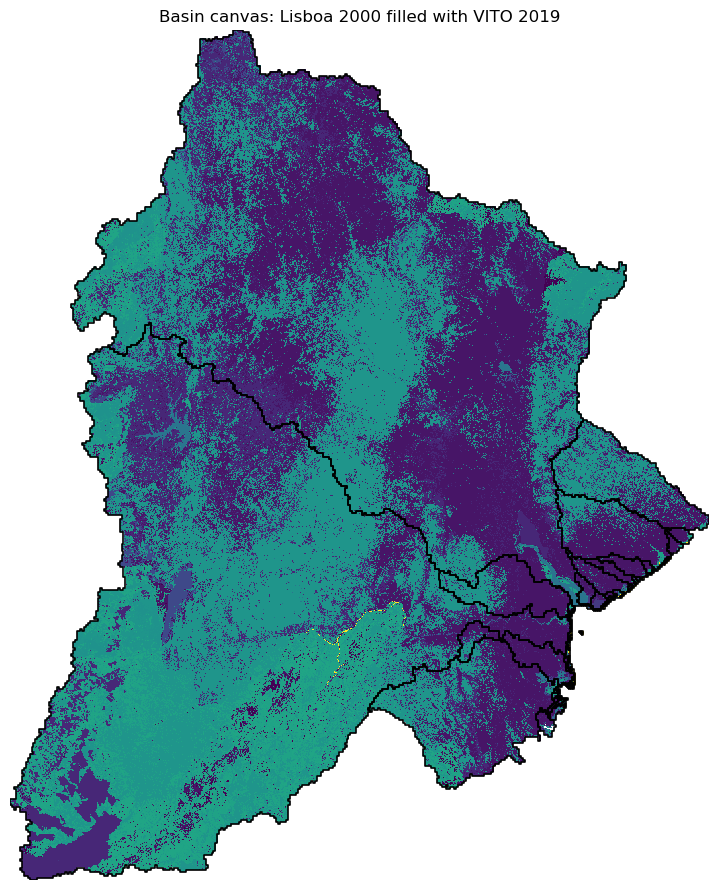

/var/folders/_6/vknc2npj5_lbbnph9btm36fw0000gn/T/ipykernel_24352/4184219618.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  basin_geom = basins.geometry.unary_union


✅ Filled raster written to: /Users/poppywebb/Documents/GECP Masters/Data_Poppy/LULC_data/lulc_map_2020_filled_with_vito2019.tif


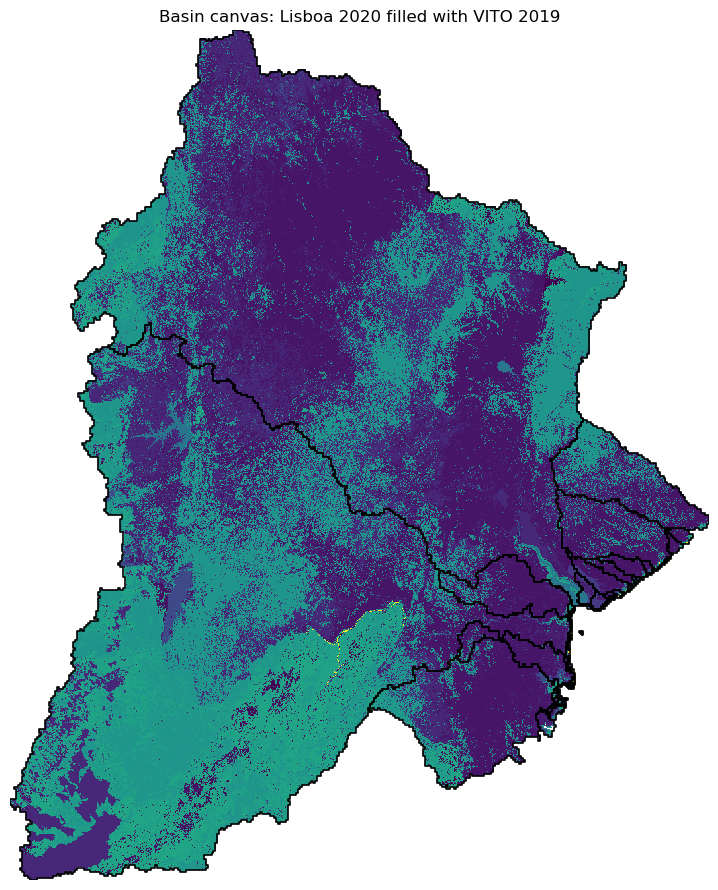

In [ ]:
# Step 4 a).  - Fill missing data areas with VITO 2019 (for Both 2000 and 2020)

import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin
from rasterio import features
import geopandas as gpd
import numpy as np
import math
import matplotlib.pyplot as plt

# ---- Inputs ----
lisboa_path_2000 = r"/Data/landuse/lulc_map_2000_BC_reclassified_clipped_basins.tif"
lisboa_path_2020 = r"/Data/landuse/lulc_map_2020_BC_reclassified_clipped_basins.tif"

vito_path   = r"/Data/landuse/clipped_vito_output.tif"
basins_path = r"/Data/gis_files/basins.geojson"

# ---- Outputs ----
out_filled_2000 = r"/Data/landuse/lulc_map_2000_filled_with_vito2019.tif"
out_filled_2020 = r"/Data/landuse/lulc_map_2020_filled_with_vito2019.tif"


def build_basin_canvas(lisboa_path, basins_path):
    """
    Build a common basin 'canvas' grid based on:
      - Lisboa CRS + resolution
      - basin bounds in that CRS
    Returns: l_crs, out_transform, (height, width), out_extent, mask_basin, basins_gdf
    """
    with rasterio.open(lisboa_path) as src_l:
        l_crs = src_l.crs
        l_resx, l_resy = src_l.res

    basins = gpd.read_file(basins_path)
    if basins.crs != l_crs:
        basins = basins.to_crs(l_crs)

    basin_geom = basins.geometry.unary_union
    minx, miny, maxx, maxy = basins.total_bounds

    width  = int(math.ceil((maxx - minx) / l_resx))
    height = int(math.ceil((maxy - miny) / abs(l_resy)))

    out_transform = from_origin(minx, maxy, l_resx, abs(l_resy))

    out_extent = [minx, minx + width * l_resx, miny, miny + height * abs(l_resy)]

    mask_basin = features.geometry_mask(
        [basin_geom],
        out_shape=(height, width),
        transform=out_transform,
        invert=True
    )

    return l_crs, out_transform, (height, width), out_extent, mask_basin, basins


def warp_to_canvas(src_path, dst_shape, dst_transform, dst_crs, dst_nodata, resampling=Resampling.nearest):
    """Reproject a single-band raster to the basin canvas grid."""
    height, width = dst_shape
    with rasterio.open(src_path) as src:
        src_nodata = src.nodata
        src_band = rasterio.band(src, 1)
        src_dtype = src.dtypes[0]

        out = np.full((height, width), dst_nodata, dtype=np.dtype(src_dtype))

        reproject(
            source=src_band,
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=resampling,
            src_nodata=src_nodata,
            dst_nodata=dst_nodata
        )
    return out


def fill_lisboa_with_vito(lisboa_path, vito_path, basins_path, out_path, plot_title=None):
    # Build basin canvas based on this Lisboa raster
    l_crs, out_transform, (h, w), out_extent, mask_basin, basins = build_basin_canvas(lisboa_path, basins_path)

    # Lisboa nodata
    with rasterio.open(lisboa_path) as src_l:
        lisboa_nodata = src_l.nodata if src_l.nodata is not None else 255
        lisboa_dtype = src_l.dtypes[0]

    # Warp both rasters to canvas
    lisboa_on = warp_to_canvas(lisboa_path, (h, w), out_transform, l_crs, dst_nodata=lisboa_nodata)
    # For VITO, choose a dst_nodata: if source nodata missing, use 0 (or 255 if you prefer)
    with rasterio.open(vito_path) as src_v:
        vito_nodata = src_v.nodata
    vito_dst_nodata = vito_nodata if vito_nodata is not None else 0
    vito_on = warp_to_canvas(vito_path, (h, w), out_transform, l_crs, dst_nodata=vito_dst_nodata)

    # Merge: inside basin, fill Lisboa nodata using VITO valid cells
    merged = lisboa_on.copy()

    lisboa_is_nodata = (merged == lisboa_nodata)
    vito_is_valid = np.ones_like(vito_on, dtype=bool) if vito_nodata is None else (vito_on != vito_dst_nodata)

    fill_where = mask_basin & lisboa_is_nodata & vito_is_valid
    merged[fill_where] = vito_on[fill_where]

    # Force outside basin to lisboa nodata
    merged[~mask_basin] = lisboa_nodata

    # Write output geotiff
    profile = {
        "driver": "GTiff",
        "height": h,
        "width": w,
        "count": 1,
        "dtype": lisboa_dtype,
        "crs": l_crs,
        "transform": out_transform,
        "nodata": lisboa_nodata,
        "compress": "lzw"
    }

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(merged.astype(lisboa_dtype), 1)

    print(f"✅ Filled raster written to: {out_path}")

    # Optional plot
    if plot_title:
        fig, ax = plt.subplots(figsize=(9, 9))
        ax.imshow(np.ma.masked_where(merged == lisboa_nodata, merged), extent=out_extent, interpolation="nearest")
        basins.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=10)
        ax.set_title(plot_title)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()


# ---- Run for both years ----
fill_lisboa_with_vito(
    lisboa_path_2000, vito_path, basins_path, out_filled_2000,
    plot_title="Basin canvas: Lisboa 2000 filled with VITO 2019"
)

fill_lisboa_with_vito(
    lisboa_path_2020, vito_path, basins_path, out_filled_2020,
    plot_title="Basin canvas: Lisboa 2020 filled with VITO 2019"
)



/var/folders/_6/vknc2npj5_lbbnph9btm36fw0000gn/T/ipykernel_34548/2268261081.py:310: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in cs.collections:
/var/folders/_6/vknc2npj5_lbbnph9btm36fw0000gn/T/ipykernel_34548/2268261081.py:310: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in cs.collections:


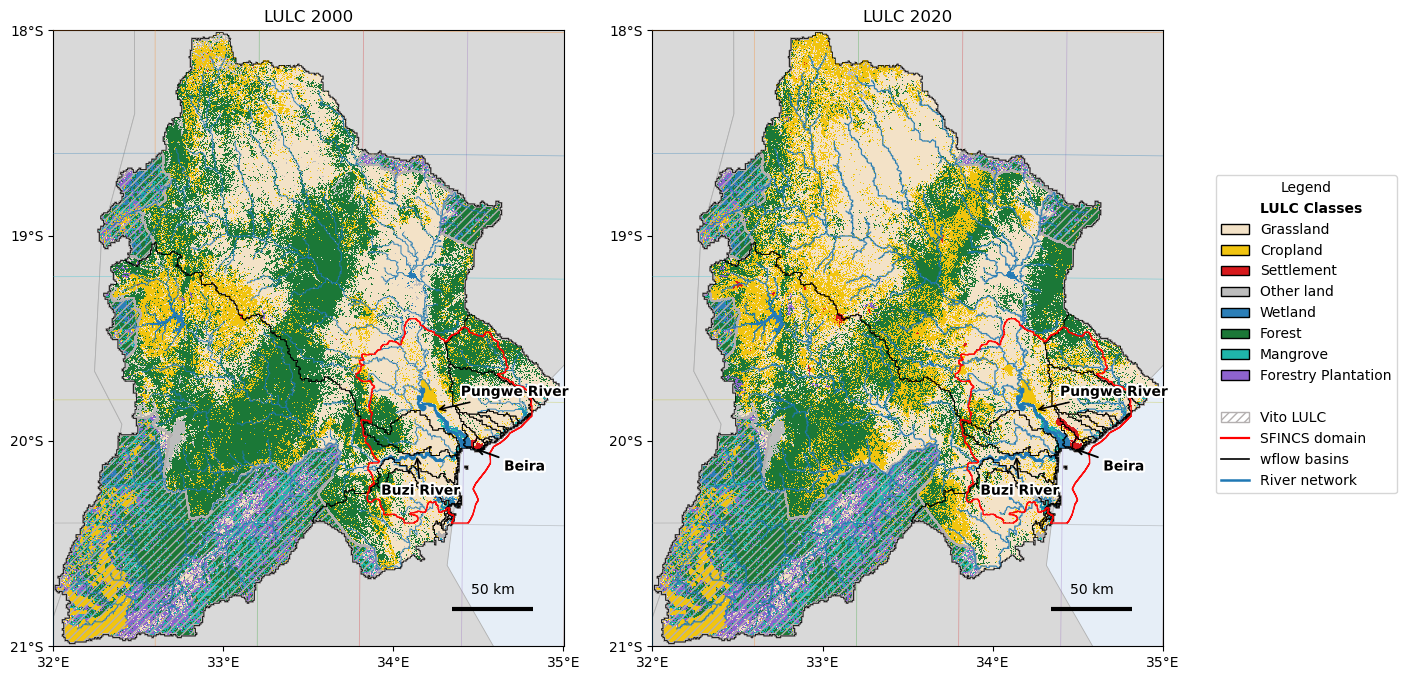

In [ ]:
#Step 4. a). Plot two LULC rasters side-by-side with consistent classes/colours

# Plotting the two maps with map elements and colours and zoomed in area. 
# Figure 2. 

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from rasterio.warp import calculate_default_transform, reproject, Resampling
from pyproj import Transformer, CRS
import matplotlib.patheffects as pe
import geopandas as gpd
from matplotlib.lines import Line2D
import cartopy.io.shapereader as shpreader

# ---- Inputs ----
r1 = r"/Data/landuse/lulc_map_2000_filled_with_vito2019.tif"
r2 = r"/Data/landuse/lulc_map_2020_filled_with_vito2019.tif"

lisboa_path_2000 = r"/Data/landuse/lulc_map_2000_BC_reclassified_clipped_basins.tif"
lisboa_path_2020 = r"/Data/landuse/lulc_map_2020_BC_reclassified_clipped_basins.tif"

basins = r"/Data/gis_files/basins.geojson"
rivers = r"/Data/gis_files/rivers.geojson"

# ✅ SFINCS domain outline (red)
sfincs = r"/Data/gis_files/sfincs_region_outline.shp"

Buzi_river = r"/Data/gis_files/Buzi_river_shapefile.shp"
Pungwe_river = r"/Data/gis_files/Pungwe_river_shapefile.shp"

# ---- Classes & colours (CONSISTENT set) ----
CLASS_LABELS = {
    30:  "Grassland",
    40:  "Cropland",
    50:  "Settlement",
    60:  "Other land",
    90:  "Wetland",
    114: "Forest",
    122: "Mangrove",
    126: "Forestry Plantation",
    255: "NoData",
}

COLORS = {
    30:  "#F3E2C7",
    40:  "#F1C40F",
    50:  "#D7191C",
    60:  "#BDBDBD",
    90:  "#2C7FB8",
    114: "#1B7837",
    122: "#1FB5AA",
    126: "#8E63CE",
    255: "#FFFFFF",
}

# 🔒 Fixed plotting order (same everywhere)
PLOT_CLASSES = [30, 40, 50, 60, 90, 114, 122, 126, 255]
cmap = ListedColormap([COLORS[c] for c in PLOT_CLASSES])
bounds = [c - 0.5 for c in PLOT_CLASSES] + [PLOT_CLASSES[-1] + 0.5]
norm = BoundaryNorm(bounds, cmap.N)

# ---------- CRS helpers ----------
def utm_epsg_from_lonlat(lon, lat):
    zone = int((lon + 180) // 6) + 1
    return (32700 + zone) if lat < 0 else (32600 + zone)

def extent_from_transform(transform, width, height):
    xmin = transform.c
    ymax = transform.f
    xmax = xmin + transform.a * width
    ymin = ymax + transform.e * height
    return [xmin, xmax, ymin, ymax]

def load_raster_maybe_utm_only_if_4326(path, nodata_fallback=255):
    with rasterio.open(path) as src:
        src_arr = src.read(1)
        src_crs = src.crs
        src_nodata = src.nodata if src.nodata is not None else nodata_fallback

        if src_crs is None:
            raise ValueError(f"No CRS found in {path}")

        epsg = src_crs.to_epsg()

        if epsg != 4326:
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
            return src_arr, extent, src_crs.to_string(), src_nodata, src.transform

        b = src.bounds
        lon_c = (b.left + b.right) / 2
        lat_c = (b.bottom + b.top) / 2
        dst_epsg = utm_epsg_from_lonlat(lon_c, lat_c)
        dst_crs = f"EPSG:{dst_epsg}"

        transform, width, height = calculate_default_transform(
            src_crs, dst_crs, src.width, src.height, *src.bounds
        )

        dst_arr = np.full((height, width), src_nodata, dtype=src_arr.dtype)

        reproject(
            source=src_arr,
            destination=dst_arr,
            src_transform=src.transform,
            src_crs=src_crs,
            src_nodata=src_nodata,
            dst_transform=transform,
            dst_crs=dst_crs,
            dst_nodata=src_nodata,
            resampling=Resampling.nearest,
        )

        extent = extent_from_transform(transform, width, height)
        return dst_arr, extent, dst_crs, src_nodata, transform

def reproject_to_match(src_arr, src_transform, src_crs, dst_transform, dst_crs, dst_shape, nodata):
    dst_arr = np.full(dst_shape, nodata, dtype=src_arr.dtype)
    reproject(
        source=src_arr,
        destination=dst_arr,
        src_transform=src_transform,
        src_crs=src_crs,
        src_nodata=nodata,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        dst_nodata=nodata,
        resampling=Resampling.nearest,
    )
    return dst_arr

# ---------- Background land/sea ----------
def load_countries_ne():
    shp = shpreader.natural_earth(resolution="110m", category="cultural", name="admin_0_countries")
    gdf = gpd.read_file(shp)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    return gdf

def add_land_sea_background(ax, extent, target_crs, gdf_countries,
                            sea_color="#E6EEF7", land_color="#D9D9D9", land_edge="#B0B0B0"):
    ax.set_facecolor(sea_color)
    land = gdf_countries.to_crs(target_crs)
    land.plot(ax=ax, color=land_color, edgecolor=land_edge, linewidth=0.6, zorder=0, alpha=1.0)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

# ---------- Lon/Lat graticule (ADD BACK) ----------
def format_lonlat(value, is_lon=True):
    deg = int(round(abs(value)))
    hemi = ("E" if value >= 0 else "W") if is_lon else ("N" if value >= 0 else "S")
    return f"{deg}°{hemi}"

def add_lonlat_graticule(ax, extent, map_crs, n_lines=6):
    xmin, xmax, ymin, ymax = extent
    crs_obj = CRS.from_user_input(map_crs)

    # If already geographic, just use native grid/ticks
    if crs_obj.is_geographic:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, linewidth=0.6, alpha=0.35)
        return

    to_lonlat = Transformer.from_crs(map_crs, "EPSG:4326", always_xy=True)
    to_map = Transformer.from_crs("EPSG:4326", map_crs, always_xy=True)

    # Find lon/lat bounds by transforming map corners
    lons, lats = [], []
    for xx in [xmin, xmax]:
        for yy in [ymin, ymax]:
            lo, la = to_lonlat.transform(xx, yy)
            lons.append(lo); lats.append(la)

    lon_min, lon_max = min(lons), max(lons)
    lat_min, lat_max = min(lats), max(lats)

    lon_lines = np.linspace(lon_min, lon_max, n_lines)
    lat_lines = np.linspace(lat_min, lat_max, n_lines)

    # Draw lon lines
    lat_samples = np.linspace(lat_min, lat_max, 200)
    for lo in lon_lines:
        xs, ys = to_map.transform(np.full_like(lat_samples, lo), lat_samples)
        ax.plot(xs, ys, linewidth=0.6, alpha=0.35, zorder=5)

    # Draw lat lines
    lon_samples = np.linspace(lon_min, lon_max, 200)
    for la in lat_lines:
        xs, ys = to_map.transform(lon_samples, np.full_like(lon_samples, la))
        ax.plot(xs, ys, linewidth=0.6, alpha=0.35, zorder=5)

    # Put tick labels in lon/lat (not meters)
    xtick_lons = np.linspace(lon_min, lon_max, 4)
    xtick_x, _ = to_map.transform(xtick_lons, np.full_like(xtick_lons, lat_min))
    ax.set_xticks(xtick_x)
    ax.set_xticklabels([format_lonlat(v, is_lon=True) for v in xtick_lons])

    ytick_lats = np.linspace(lat_min, lat_max, 4)
    _, ytick_y = to_map.transform(np.full_like(ytick_lats, lon_min), ytick_lats)
    ax.set_yticks(ytick_y)
    ax.set_yticklabels([format_lonlat(v, is_lon=False) for v in ytick_lats])

# ---------- Map decorations ----------
def add_scale_bar_fixed(ax, extent, length_km=50, pad=0.06, linewidth=3):
    xmin, xmax, ymin, ymax = extent
    width_m = xmax - xmin
    if width_m <= 0:
        return
    length_m = float(length_km) * 1000.0
    frac = min(length_m / width_m, 0.6)

    x1 = 1 - pad
    x0 = x1 - frac
    y0 = pad

    ax.plot([x0, x1], [y0, y0],
            transform=ax.transAxes,
            color="black",
            linewidth=linewidth,
            solid_capstyle="butt",
            zorder=140)

    ax.text((x0 + x1) / 2, y0 + 0.02,
            f"{length_km} km",
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=10,
            color="black",
            zorder=141)

def plot_beira_arrow(ax, lon, lat, dst_crs, label="Beira",
                     dx_frac=0.06, dy_frac=-0.03, fontsize=10):
    transformer = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    x, y = transformer.transform(lon, lat)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    dx = dx_frac * (xmax - xmin)
    dy = dy_frac * (ymax - ymin)

    ann = ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left", va="center",
        fontsize=fontsize,
        fontweight="bold",
        color="black",
        arrowprops=dict(arrowstyle="->", lw=1.4, color="black"),
        zorder=201,
        clip_on=False
    )
    ann.set_path_effects([pe.Stroke(linewidth=3, foreground="white"), pe.Normal()])

# ---------- Vector overlays ----------
def load_vector(path, target_crs):
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f"Vector has no CRS: {path}")
    if str(gdf.crs) != str(target_crs):
        gdf = gdf.to_crs(target_crs)
    return gdf

def add_basins_outline(ax, basins_gdf, lw=0.6):
    basins_gdf.boundary.plot(ax=ax, color="black", linewidth=lw, alpha=0.95, zorder=135)

def add_rivers(ax, rivers_gdf, lw=0.7):
    rivers_gdf.plot(ax=ax, color="#1f78b4", linewidth=lw, alpha=0.9, zorder=121)

def add_sfincs_outline(ax, sfincs_gdf, lw=1.0):
    sfincs_gdf.boundary.plot(ax=ax, color="red", linewidth=lw, alpha=0.95, zorder=136)

def label_line_gdf_with_arrow(ax, gdf, text, dx_frac=0.06, dy_frac=0.03, fontsize=10):
    gdf = gdf[gdf.geometry.notnull()].copy()
    if len(gdf) == 0:
        return
    geom = gdf.geometry.iloc[gdf.length.values.argmax()]
    try:
        p = geom.interpolate(0.55, normalized=True)
    except Exception:
        p = geom.representative_point()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    dx = dx_frac * (xmax - xmin)
    dy = dy_frac * (ymax - ymin)

    txt = ax.annotate(
        text,
        xy=(p.x, p.y),
        xytext=(p.x + dx, p.y + dy),
        textcoords="data",
        ha="left", va="center",
        fontsize=fontsize, fontweight="bold", color="black",
        arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
        zorder=160
    )
    txt.set_path_effects([pe.Stroke(linewidth=3, foreground="white"), pe.Normal()])

def add_merged_hatch(ax, mask, extent, hatch="////", hatch_color="#B4B0B0", hatch_lw=0.9, zorder=130):
    m = np.flipud(mask.astype(np.uint8))
    xmin, xmax, ymin, ymax = extent
    ny, nx = m.shape
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    X, Y = np.meshgrid(x, y)

    cs = ax.contourf(X, Y, m, levels=[0.5, 1.5], colors="none", hatches=[hatch], zorder=zorder)
    for coll in cs.collections:
        coll.set_edgecolor(hatch_color)
        coll.set_linewidth(hatch_lw)
        coll.set_facecolor((0, 0, 0, 0))

# ---- Beira lon/lat ----
beira_lon, beira_lat = 34.85, -19.84

# ---- Load rasters ----
a1, ex1, crs1, nodata1, t1 = load_raster_maybe_utm_only_if_4326(r1)
a2, ex2, crs2, nodata2, t2 = load_raster_maybe_utm_only_if_4326(r2)

b1, bx1, bcrs1, bnodata1, bt1 = load_raster_maybe_utm_only_if_4326(lisboa_path_2000, nodata_fallback=nodata1)
b2, bx2, bcrs2, bnodata2, bt2 = load_raster_maybe_utm_only_if_4326(lisboa_path_2020, nodata_fallback=nodata2)

if str(bcrs1) != str(crs1) or b1.shape != a1.shape:
    b1 = reproject_to_match(b1, bt1, bcrs1, t1, crs1, a1.shape, bnodata1)
if str(bcrs2) != str(crs2) or b2.shape != a2.shape:
    b2 = reproject_to_match(b2, bt2, bcrs2, t2, crs2, a2.shape, bnodata2)

a1m = np.ma.masked_where(a1 == nodata1, a1)
a2m = np.ma.masked_where(a2 == nodata2, a2)

merged1 = (a1 != nodata1) & (b1 == bnodata1)
merged2 = (a2 != nodata2) & (b2 == bnodata2)

# ---- Load vectors ----
basins_gdf_1 = load_vector(basins, crs1)
basins_gdf_2 = load_vector(basins, crs2)

rivers_gdf_1 = load_vector(rivers, crs1)
rivers_gdf_2 = load_vector(rivers, crs2)

buzi_gdf_1 = load_vector(Buzi_river, crs1)
buzi_gdf_2 = load_vector(Buzi_river, crs2)

pungwe_gdf_1 = load_vector(Pungwe_river, crs1)
pungwe_gdf_2 = load_vector(Pungwe_river, crs2)

sfincs_gdf_1 = load_vector(sfincs, crs1)
sfincs_gdf_2 = load_vector(sfincs, crs2)

countries_gdf = load_countries_ne()

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Panel 2000
add_land_sea_background(axes[0], ex1, crs1, countries_gdf)
axes[0].imshow(a1m, cmap=cmap, norm=norm, extent=ex1, interpolation="nearest", aspect="auto", zorder=10)
axes[0].set_title("LULC 2000")
add_scale_bar_fixed(axes[0], ex1, length_km=50)
plot_beira_arrow(axes[0], beira_lon, beira_lat, crs1)

add_merged_hatch(axes[0], merged1, ex1, hatch="////", hatch_color="#B4B0B0", hatch_lw=0.9, zorder=120)
add_basins_outline(axes[0], basins_gdf_1, lw=0.6)
add_rivers(axes[0], rivers_gdf_1, lw=0.7)
buzi_gdf_1.plot(ax=axes[0], color="#1f78b4", linewidth=1.9, zorder=130)
pungwe_gdf_1.plot(ax=axes[0], color="#1f78b4", linewidth=1.9, zorder=130)
label_line_gdf_with_arrow(axes[0], buzi_gdf_1, "Buzi River", dx_frac=-0.07, dy_frac=-0.06)
label_line_gdf_with_arrow(axes[0], pungwe_gdf_1, "Pungwe River", dx_frac=0.05, dy_frac=0.03)
add_sfincs_outline(axes[0], sfincs_gdf_1, lw=1.0)

# ✅ grid + lon/lat tick labels back
add_lonlat_graticule(axes[0], ex1, crs1, n_lines=6)

# Panel 2020
add_land_sea_background(axes[1], ex2, crs2, countries_gdf)
axes[1].imshow(a2m, cmap=cmap, norm=norm, extent=ex2, interpolation="nearest", aspect="auto", zorder=10)
axes[1].set_title("LULC 2020")
add_scale_bar_fixed(axes[1], ex2, length_km=50)
plot_beira_arrow(axes[1], beira_lon, beira_lat, crs2)

add_merged_hatch(axes[1], merged2, ex2, hatch="////", hatch_color="#B4B0B0", hatch_lw=0.9, zorder=120)
add_basins_outline(axes[1], basins_gdf_2, lw=0.6)
add_rivers(axes[1], rivers_gdf_2, lw=0.9)
buzi_gdf_2.plot(ax=axes[1], color="#1f78b4", linewidth=1.9, zorder=130)
pungwe_gdf_2.plot(ax=axes[1], color="#1f78b4", linewidth=1.9, zorder=130)
label_line_gdf_with_arrow(axes[1], buzi_gdf_2, "Buzi River", dx_frac=-0.07, dy_frac=-0.06)
label_line_gdf_with_arrow(axes[1], pungwe_gdf_2, "Pungwe River", dx_frac=0.05, dy_frac=0.03)
add_sfincs_outline(axes[1], sfincs_gdf_2, lw=1.0)

# ✅ grid + lon/lat tick labels back
add_lonlat_graticule(axes[1], ex2, crs2, n_lines=6)

# ---------- Legend ----------
lulc_title_handle = Line2D([], [], color="none", label="LULC Classes")
lulc_handles = [Patch(facecolor=COLORS[c], edgecolor="black", label=CLASS_LABELS[c])
                for c in PLOT_CLASSES if c != 255]
spacer = Line2D([], [], linestyle="none", label="")

vito_handle = Patch(facecolor="white", edgecolor="#B4B0B0", hatch="////", label="Vito LULC")
sfincs_handle = Line2D([0], [0], color="red", lw=1.6, label="SFINCS domain")

line_handles = [
    Line2D([0], [0], color="black", lw=1.2, label="wflow basins"),
    Line2D([0], [0], color="#1f78b4", lw=1.8, label="River network"),
]

legend_handles = [lulc_title_handle] + lulc_handles + [spacer] + [vito_handle] + [sfincs_handle] + line_handles

leg = fig.legend(handles=legend_handles, title="Legend",
                 loc="center right", bbox_to_anchor=(0.98, 0.5), frameon=True)
for text in leg.get_texts():
    if text.get_text() == "LULC Classes":
        text.set_weight("bold")

fig.subplots_adjust(right=0.84, wspace=0.10)
plt.show()


/var/folders/_6/vknc2npj5_lbbnph9btm36fw0000gn/T/ipykernel_37215/332137460.py:302: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in cs.collections:
/var/folders/_6/vknc2npj5_lbbnph9btm36fw0000gn/T/ipykernel_37215/332137460.py:302: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in cs.collections:
/var/folders/_6/vknc2npj5_lbbnph9btm36fw0000gn/T/ipykernel_37215/332137460.py:302: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in cs.collections:
/var/folders/_6/vknc2npj5_lbbnph9btm36fw0000gn/T/ipykernel_37215/332137460.py:302: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in cs.collections:


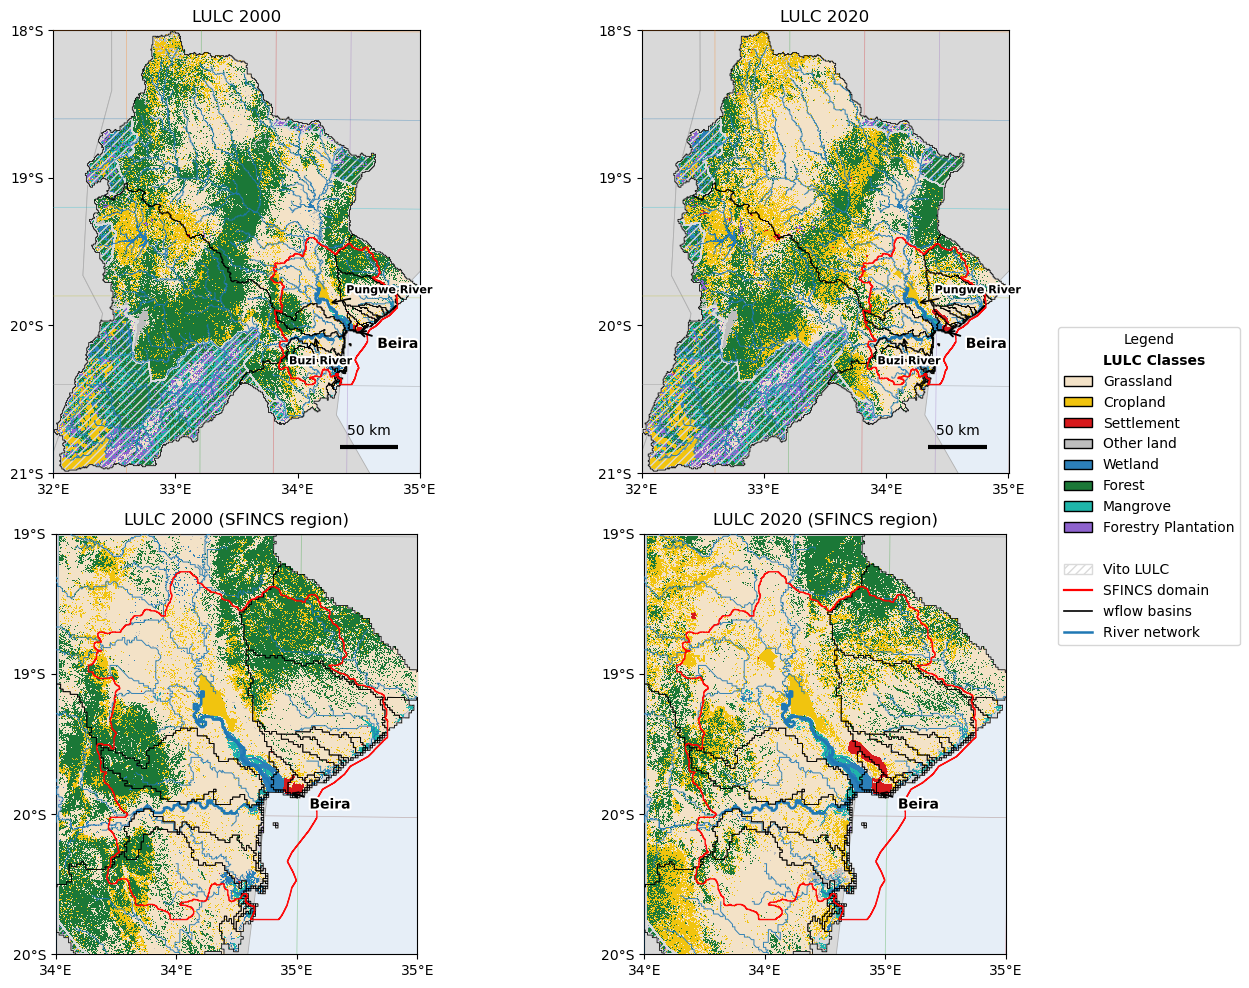

In [ ]:
# Step 4.b The full code used to create Figure 2. 

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from rasterio.warp import calculate_default_transform, reproject, Resampling
from pyproj import Transformer, CRS
import matplotlib.patheffects as pe
import geopandas as gpd
from matplotlib.lines import Line2D

# Code to create Figure 2. 

# ---- Inputs ----
r1 = r"/Data/landuse/lulc_map_2000_filled_with_vito2019.tif"
r2 = r"/Data/landuse/lulc_map_2020_filled_with_vito2019.tif"

lisboa_path_2000 = r"Data/landuse/lulc_map_2000_BC_reclassified_clipped_basins.tif"
lisboa_path_2020 = r"/Data/landuse/lulc_map_2020_BC_reclassified_clipped_basins.tif"

basins = r"/Data/basins.geojson"
rivers = r"/Data/rivers.geojson"

# ✅ SFINCS domain outline (red)
sfincs = r"/Data/sfincs_region_outline.shp"

Buzi_river = r"/Data/Buzi_river_shapefile.shp"
Pungwe_river = r"/Data/Pungwe_river_shapefile.shp"

# ---- Beira lon/lat ----
beira_lon, beira_lat = 34.85, -19.84

# ---- Classes & colours ----
CLASS_LABELS = {
    30:  "Grassland",
    40:  "Cropland",
    50:  "Settlement",
    60:  "Other land",
    90:  "Wetland",
    114: "Forest",
    122: "Mangrove",
    126: "Forestry Plantation",
    255: "NoData",
}
COLORS = {
    30:  "#F3E2C7",
    40:  "#F1C40F",
    50:  "#D7191C",
    60:  "#BDBDBD",
    90:  "#2C7FB8",
    114: "#1B7837",
    122: "#1FB5AA",
    126: "#8E63CE",
    255: "#FFFFFF",
}
PLOT_CLASSES = [30, 40, 50, 60, 90, 114, 122, 126, 255]
cmap = ListedColormap([COLORS[c] for c in PLOT_CLASSES])
bounds = [c - 0.5 for c in PLOT_CLASSES] + [PLOT_CLASSES[-1] + 0.5]
norm = BoundaryNorm(bounds, cmap.N)

# ---------- CRS helpers ----------
def utm_epsg_from_lonlat(lon, lat):
    zone = int((lon + 180) // 6) + 1
    return (32700 + zone) if lat < 0 else (32600 + zone)

def extent_from_transform(transform, width, height):
    xmin = transform.c
    ymax = transform.f
    xmax = xmin + transform.a * width
    ymin = ymax + transform.e * height
    return [xmin, xmax, ymin, ymax]

def load_raster_maybe_utm_only_if_4326(path, nodata_fallback=255):
    with rasterio.open(path) as src:
        src_arr = src.read(1)
        src_crs = src.crs
        src_nodata = src.nodata if src.nodata is not None else nodata_fallback
        if src_crs is None:
            raise ValueError(f"No CRS found in {path}")

        epsg = src_crs.to_epsg()
        if epsg != 4326:
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
            return src_arr, extent, src_crs.to_string(), src_nodata, src.transform

        b = src.bounds
        lon_c = (b.left + b.right) / 2
        lat_c = (b.bottom + b.top) / 2
        dst_epsg = utm_epsg_from_lonlat(lon_c, lat_c)
        dst_crs = f"EPSG:{dst_epsg}"

        transform, width, height = calculate_default_transform(
            src_crs, dst_crs, src.width, src.height, *src.bounds
        )

        dst_arr = np.full((height, width), src_nodata, dtype=src_arr.dtype)

        reproject(
            source=src_arr,
            destination=dst_arr,
            src_transform=src.transform,
            src_crs=src_crs,
            src_nodata=src_nodata,
            dst_transform=transform,
            dst_crs=dst_crs,
            dst_nodata=src_nodata,
            resampling=Resampling.nearest,
        )

        extent = extent_from_transform(transform, width, height)
        return dst_arr, extent, dst_crs, src_nodata, transform

def reproject_to_match(src_arr, src_transform, src_crs, dst_transform, dst_crs, dst_shape, nodata):
    dst_arr = np.full(dst_shape, nodata, dtype=src_arr.dtype)
    reproject(
        source=src_arr,
        destination=dst_arr,
        src_transform=src_transform,
        src_crs=src_crs,
        src_nodata=nodata,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        dst_nodata=nodata,
        resampling=Resampling.nearest,
    )
    return dst_arr

# ---------- Background land/sea ----------
def load_countries_ne():
    shp = shpreader.natural_earth(resolution="110m", category="cultural", name="admin_0_countries")
    gdf = gpd.read_file(shp)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    return gdf

def add_land_sea_background(ax, extent, target_crs, gdf_countries,
                            sea_color="#E6EEF7", land_color="#D9D9D9", land_edge="#B0B0B0"):
    ax.set_facecolor(sea_color)
    land = gdf_countries.to_crs(target_crs)
    land.plot(ax=ax, color=land_color, edgecolor=land_edge, linewidth=0.6, zorder=0, alpha=1.0)
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

# ---------- Lon/Lat graticule ----------
def format_lonlat(value, is_lon=True):
    deg = int(round(abs(value)))
    hemi = ("E" if value >= 0 else "W") if is_lon else ("N" if value >= 0 else "S")
    return f"{deg}°{hemi}"

def add_lonlat_graticule(ax, extent, map_crs, n_lines=6):
    xmin, xmax, ymin, ymax = extent
    crs_obj = CRS.from_user_input(map_crs)

    if crs_obj.is_geographic:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, linewidth=0.6, alpha=0.35)
        return

    to_lonlat = Transformer.from_crs(map_crs, "EPSG:4326", always_xy=True)
    to_map = Transformer.from_crs("EPSG:4326", map_crs, always_xy=True)

    lons, lats = [], []
    for xx in [xmin, xmax]:
        for yy in [ymin, ymax]:
            lo, la = to_lonlat.transform(xx, yy)
            lons.append(lo); lats.append(la)

    lon_min, lon_max = min(lons), max(lons)
    lat_min, lat_max = min(lats), max(lats)

    lon_lines = np.linspace(lon_min, lon_max, n_lines)
    lat_lines = np.linspace(lat_min, lat_max, n_lines)

    lat_samples = np.linspace(lat_min, lat_max, 200)
    for lo in lon_lines:
        xs, ys = to_map.transform(np.full_like(lat_samples, lo), lat_samples)
        ax.plot(xs, ys, linewidth=0.6, alpha=0.35, zorder=5)

    lon_samples = np.linspace(lon_min, lon_max, 200)
    for la in lat_lines:
        xs, ys = to_map.transform(lon_samples, np.full_like(lon_samples, la))
        ax.plot(xs, ys, linewidth=0.6, alpha=0.35, zorder=5)

    xtick_lons = np.linspace(lon_min, lon_max, 4)
    xtick_x, _ = to_map.transform(xtick_lons, np.full_like(xtick_lons, lat_min))
    ax.set_xticks(xtick_x)
    ax.set_xticklabels([format_lonlat(v, is_lon=True) for v in xtick_lons])

    ytick_lats = np.linspace(lat_min, lat_max, 4)
    _, ytick_y = to_map.transform(np.full_like(ytick_lats, lon_min), ytick_lats)
    ax.set_yticks(ytick_y)
    ax.set_yticklabels([format_lonlat(v, is_lon=False) for v in ytick_lats])

# ---------- Decorations ----------
def add_scale_bar_fixed(ax, extent, length_km=50, pad=0.06, linewidth=3):
    xmin, xmax, ymin, ymax = extent
    width_m = xmax - xmin
    if width_m <= 0:
        return
    length_m = float(length_km) * 1000.0
    frac = min(length_m / width_m, 0.6)

    x1 = 1 - pad
    x0 = x1 - frac
    y0 = pad

    ax.plot([x0, x1], [y0, y0],
            transform=ax.transAxes, color="black",
            linewidth=linewidth, solid_capstyle="butt", zorder=140)

    ax.text((x0 + x1) / 2, y0 + 0.02, f"{length_km} km",
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=10, color="black", zorder=141)

def plot_beira_arrow(ax, lon, lat, dst_crs, label="Beira",
                     dx_frac=0.06, dy_frac=-0.03, fontsize=10):
    transformer = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    x, y = transformer.transform(lon, lat)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    dx = dx_frac * (xmax - xmin)
    dy = dy_frac * (ymax - ymin)

    ann = ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left", va="center",
        fontsize=fontsize, fontweight="bold", color="black",
        arrowprops=dict(arrowstyle="->", lw=1.4, color="black"),
        zorder=201, clip_on=False
    )
    ann.set_path_effects([pe.Stroke(linewidth=3, foreground="white"), pe.Normal()])

# ---------- Vector overlays ----------
def load_vector(path, target_crs):
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f"Vector has no CRS: {path}")
    if str(gdf.crs) != str(target_crs):
        gdf = gdf.to_crs(target_crs)
    return gdf

def add_basins_outline(ax, basins_gdf, lw=0.6):
    basins_gdf.boundary.plot(ax=ax, color="black", linewidth=lw, alpha=0.95, zorder=135)

def add_rivers(ax, rivers_gdf, lw=0.7):
    rivers_gdf.plot(ax=ax, color="#1f78b4", linewidth=lw, alpha=0.9, zorder=121)

def add_sfincs_outline(ax, sfincs_gdf, lw=1.0):
    sfincs_gdf.boundary.plot(ax=ax, color="red", linewidth=lw, alpha=0.95, zorder=136)

def label_line_gdf_with_arrow(ax, gdf, text, dx_frac=0.06, dy_frac=0.03, fontsize=8):
    gdf = gdf[gdf.geometry.notnull()].copy()
    if len(gdf) == 0:
        return
    geom = gdf.geometry.iloc[gdf.length.values.argmax()]
    try:
        p = geom.interpolate(0.55, normalized=True)
    except Exception:
        p = geom.representative_point()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    dx = dx_frac * (xmax - xmin)
    dy = dy_frac * (ymax - ymin)

    txt = ax.annotate(
        text,
        xy=(p.x, p.y),
        xytext=(p.x + dx, p.y + dy),
        textcoords="data",
        ha="left", va="center",
        fontsize=fontsize, fontweight="bold", color="black",
        arrowprops=dict(arrowstyle="->", lw=1.2, color="black"),
        zorder=160
    )
    txt.set_path_effects([pe.Stroke(linewidth=3, foreground="white"), pe.Normal()])

# ---------- Hatch overlay ----------
def add_merged_hatch(ax, mask, extent, hatch="////", hatch_color="#DADADA", hatch_lw=0.7, zorder=130):
    # <<< CHANGED: lighter hatch + thinner stroke
    m = np.flipud(mask.astype(np.uint8))
    xmin, xmax, ymin, ymax = extent
    ny, nx = m.shape
    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)
    X, Y = np.meshgrid(x, y)

    cs = ax.contourf(X, Y, m, levels=[0.5, 1.5], colors="none", hatches=[hatch], zorder=zorder)
    for coll in cs.collections:
        coll.set_edgecolor(hatch_color)
        coll.set_linewidth(hatch_lw)
        coll.set_facecolor((0, 0, 0, 0))

# ==========================================================
# ✅ TRUE raster crop to a zoom extent (NO distortion)
# ==========================================================
def crop_array_to_extent(arr, transform, extent):
    xmin, xmax, ymin, ymax = extent
    r0, c0 = rowcol(transform, xmin, ymax)
    r1, c1 = rowcol(transform, xmax, ymin)

    rmin, rmax = sorted([r0, r1])
    cmin, cmax = sorted([c0, c1])

    rmin = max(rmin, 0)
    cmin = max(cmin, 0)
    rmax = min(rmax, arr.shape[0])
    cmax = min(cmax, arr.shape[1])

    cropped = arr[rmin:rmax, cmin:cmax]
    cropped_transform = transform * Affine.translation(cmin, rmin)

    h, w = cropped.shape
    cropped_extent = extent_from_transform(cropped_transform, w, h)
    return cropped, cropped_transform, cropped_extent

def sfincs_zoom_extent(sfincs_gdf, buffer_frac=0.10):
    xmin, ymin, xmax, ymax = sfincs_gdf.total_bounds
    dx = xmax - xmin
    dy = ymax - ymin
    bx = buffer_frac * dx
    by = buffer_frac * dy
    return [xmin - bx, xmax + bx, ymin - by, ymax + by]

# ==========================================================
# ✅ Panel plotter: can do full or zoom (cropped)
# ==========================================================
def plot_panel(ax, title,
               a_masked, transform, extent, crs_str, merged_mask,
               countries_gdf, basins_gdf, rivers_gdf, buzi_gdf, pungwe_gdf, sfincs_gdf,
               zoom_extent=None,
               show_scale=True,
               graticule_lines=6,
               show_labels=True):

    plot_extent = extent
    a_plot = a_masked
    m_plot = merged_mask

    if zoom_extent is not None:
        a_plot, _, plot_extent = crop_array_to_extent(a_masked, transform, zoom_extent)
        m_plot, _, _ = crop_array_to_extent(merged_mask.astype(np.uint8), transform, zoom_extent)
        m_plot = m_plot.astype(bool)

    add_land_sea_background(ax, plot_extent, crs_str, countries_gdf)
    ax.imshow(a_plot, cmap=cmap, norm=norm, extent=plot_extent, interpolation="nearest", aspect="auto", zorder=10)
    ax.set_title(title)

    plot_beira_arrow(ax, beira_lon, beira_lat, crs_str, label="Beira", dx_frac=0.06, dy_frac=-0.03)

    # <<< CHANGED: hatch is lighter via default add_merged_hatch() settings above
    add_merged_hatch(ax, m_plot, plot_extent, hatch="////", hatch_color="#DADADA", hatch_lw=0.7, zorder=120)

    add_basins_outline(ax, basins_gdf, lw=0.6)
    add_rivers(ax, rivers_gdf, lw=0.7)
    buzi_gdf.plot(ax=ax, color="#1f78b4", linewidth=1.9, zorder=130)
    pungwe_gdf.plot(ax=ax, color="#1f78b4", linewidth=1.9, zorder=130)

    if show_labels:
        label_line_gdf_with_arrow(ax, buzi_gdf, "Buzi River", dx_frac=-0.07, dy_frac=-0.06)
        label_line_gdf_with_arrow(ax, pungwe_gdf, "Pungwe River", dx_frac=0.05, dy_frac=0.03)

    add_sfincs_outline(ax, sfincs_gdf, lw=1.0)

    if show_scale:
        add_scale_bar_fixed(ax, plot_extent, length_km=50)

    add_lonlat_graticule(ax, plot_extent, crs_str, n_lines=graticule_lines)

# ==========================================================
# Load rasters
# ==========================================================
a1, ex1, crs1, nodata1, t1 = load_raster_maybe_utm_only_if_4326(r1)
a2, ex2, crs2, nodata2, t2 = load_raster_maybe_utm_only_if_4326(r2)

b1, bx1, bcrs1, bnodata1, bt1 = load_raster_maybe_utm_only_if_4326(lisboa_path_2000, nodata_fallback=nodata1)
b2, bx2, bcrs2, bnodata2, bt2 = load_raster_maybe_utm_only_if_4326(lisboa_path_2020, nodata_fallback=nodata2)

if str(bcrs1) != str(crs1) or b1.shape != a1.shape:
    b1 = reproject_to_match(b1, bt1, bcrs1, t1, crs1, a1.shape, bnodata1)
if str(bcrs2) != str(crs2) or b2.shape != a2.shape:
    b2 = reproject_to_match(b2, bt2, bcrs2, t2, crs2, a2.shape, bnodata2)

a1m = np.ma.masked_where(a1 == nodata1, a1)
a2m = np.ma.masked_where(a2 == nodata2, a2)

merged1 = (a1 != nodata1) & (b1 == bnodata1)
merged2 = (a2 != nodata2) & (b2 == bnodata2)

# ==========================================================
# Load vectors (reproject to each CRS)
# ==========================================================
countries_gdf = load_countries_ne()

basins_gdf_1 = load_vector(basins, crs1)
basins_gdf_2 = load_vector(basins, crs2)

rivers_gdf_1 = load_vector(rivers, crs1)
rivers_gdf_2 = load_vector(rivers, crs2)

buzi_gdf_1 = load_vector(Buzi_river, crs1)
buzi_gdf_2 = load_vector(Buzi_river, crs2)

pungwe_gdf_1 = load_vector(Pungwe_river, crs1)
pungwe_gdf_2 = load_vector(Pungwe_river, crs2)

sfincs_gdf_1 = load_vector(sfincs, crs1)
sfincs_gdf_2 = load_vector(sfincs, crs2)

zoom_ex1 = sfincs_zoom_extent(sfincs_gdf_1, buffer_frac=0.10)
zoom_ex2 = sfincs_zoom_extent(sfincs_gdf_2, buffer_frac=0.10)

# ==========================================================
# ✅ 2x2 figure spacing tweaks
# ==========================================================
fig = plt.figure(figsize=(16, 12))

gs = GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1.0, 0.95],
    hspace=0.14,   # <<< CHANGED: tighter top/bottom gap
    wspace=0.0015
)

ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])

plot_panel(ax00, "LULC 2000", a1m, t1, ex1, crs1, merged1,
           countries_gdf, basins_gdf_1, rivers_gdf_1, buzi_gdf_1, pungwe_gdf_1, sfincs_gdf_1,
           zoom_extent=None, show_scale=True, graticule_lines=6, show_labels=True)

plot_panel(ax01, "LULC 2020", a2m, t2, ex2, crs2, merged2,
           countries_gdf, basins_gdf_2, rivers_gdf_2, buzi_gdf_2, pungwe_gdf_2, sfincs_gdf_2,
           zoom_extent=None, show_scale=True, graticule_lines=6, show_labels=True)

plot_panel(ax10, "LULC 2000 (SFINCS region)", a1m, t1, ex1, crs1, merged1,
           countries_gdf, basins_gdf_1, rivers_gdf_1, buzi_gdf_1, pungwe_gdf_1, sfincs_gdf_1,
           zoom_extent=zoom_ex1, show_scale=False, graticule_lines=4, show_labels=False)

plot_panel(ax11, "LULC 2020 (SFINCS region)", a2m, t2, ex2, crs2, merged2,
           countries_gdf, basins_gdf_2, rivers_gdf_2, buzi_gdf_2, pungwe_gdf_2, sfincs_gdf_2,
           zoom_extent=zoom_ex2, show_scale=False, graticule_lines=4, show_labels=False)

# ---------- Legend ----------
lulc_title_handle = Line2D([], [], color="none", label="LULC Classes")
lulc_handles = [Patch(facecolor=COLORS[c], edgecolor="black", label=CLASS_LABELS[c])
                for c in PLOT_CLASSES if c != 255]
spacer = Line2D([], [], linestyle="none", label="")

# <<< CHANGED: lighter hatch legend edge too
vito_handle = Patch(facecolor="white", edgecolor="#DADADA", hatch="////", label="Vito LULC")

sfincs_handle = Line2D([0], [0], color="red", lw=1.6, label="SFINCS domain")

line_handles = [
    Line2D([0], [0], color="black", lw=1.2, label="wflow basins"),
    Line2D([0], [0], color="#1f78b4", lw=1.8, label="River network"),
]

legend_handles = [lulc_title_handle] + lulc_handles + [spacer] + [vito_handle] + [sfincs_handle] + line_handles

leg = fig.legend(
    handles=legend_handles,
    title="Legend",
    loc="center right",
    bbox_to_anchor=(0.94, 0.5),  # <<< CHANGED: move legend left
    frameon=True
)

for text in leg.get_texts():
    if text.get_text() == "LULC Classes":
        text.set_weight("bold")

# <<< CHANGED: more space to the right plot area (because legend moved left)
fig.subplots_adjust(right=0.86)

plt.show()
